In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

Regression

In [3]:
data = joblib.load("pkl_files/preprocessed_regression.pkl")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (171, 17)
X_test shape: (43, 17)
y_train shape: (171,)
y_test shape: (43,)


In [4]:
lr= LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

In [5]:
linear_mae = mean_absolute_error(y_test,lr_predictions)
linear_mse = mean_squared_error(y_test,lr_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test,lr_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 127916509.94284025
MSE: 4.442649116250583e+16
RMSE: 210775926.4301923
R² Score: 0.966344531868382


In [6]:
rfr_model = RandomForestRegressor(n_estimators=100,random_state=42)
rfr_model.fit(X_train, y_train)
rfr_predictions = rfr_model.predict(X_test)

In [7]:
rfr_mae = mean_absolute_error(y_test,rfr_predictions)
rfr_mse = mean_squared_error(y_test,rfr_predictions)
rfr_rmse = np.sqrt(rfr_mse)
rfr_r2 = r2_score(y_test,rfr_predictions)

print("Random Forest Regressor Results")
print("MAE:", rfr_mae)
print("MSE:", rfr_mse)
print("RMSE:", rfr_rmse)
print("R² Score:", rfr_r2)

Random Forest Regressor Results
MAE: 128244837.20930232
MSE: 6.120360917916279e+16
RMSE: 247393632.05054975
R² Score: 0.9536349582339346


In [8]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest Regressor"],
    "MAE": [linear_mae,rfr_mae],
    "MSE": [linear_mse,rfr_mse],
    "RMSE": [linear_rmse,rfr_rmse],
    "R2": [linear_r2,rfr_r2]

})

regression_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.279165e+08,4.442649e+16,2.107759e+08,0.966345
1,Random Forest Regressor,1.282448e+08,6.120361e+16,2.473936e+08,0.953635


In [9]:
best_regression_model = lr
joblib.dump(best_regression_model, "pkl_files/best_regression_model.pkl")

['pkl_files/best_regression_model.pkl']

classification

In [10]:
cls_data = joblib.load("pkl_files/preprocessed_classification.pkl")

Xcls_train = cls_data["X_train"]
Xcls_test = cls_data["X_test"]
ycls_train = cls_data["y_train"]
ycls_test = cls_data["y_test"]


print("X_train shape:", Xcls_train.shape)
print("X_test shape:", Xcls_test.shape)
print("y_train shape:", ycls_train.shape)
print("y_test shape:", ycls_test.shape)

X_train shape: (171, 17)
X_test shape: (43, 17)
y_train shape: (171,)
y_test shape: (43,)


In [11]:
lgr_model = LogisticRegression(max_iter=1000,random_state=42)
lgr_model.fit(Xcls_train, ycls_train)
lgr_predictions = lgr_model.predict(Xcls_test)

In [12]:
lgr_accuracy = accuracy_score(ycls_test,lgr_predictions)
lgr_precision = precision_score(ycls_test,lgr_predictions, average="weighted")
lgr_recall = recall_score(ycls_test,lgr_predictions,average="weighted")
lgr_f1 = f1_score(ycls_test,lgr_predictions,average="weighted")


print("Logistic Regression Results")
print("Accuracy:", lgr_accuracy)
print("Precision:", lgr_precision)
print("Recall:", lgr_recall)
print("F1-score:", lgr_f1)

Logistic Regression Results
Accuracy: 0.7209302325581395
Precision: 0.7209302325581395
Recall: 0.7209302325581395
F1-score: 0.7209302325581395


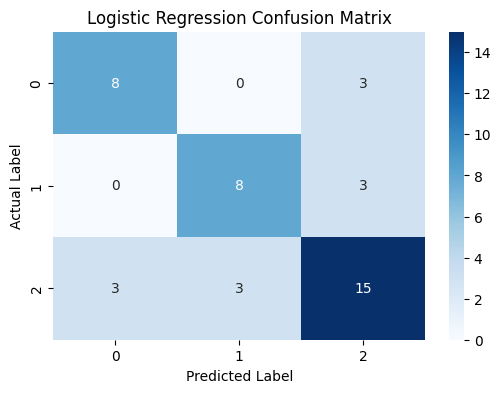

In [13]:
lr_confusion_matrix = confusion_matrix(ycls_test,lgr_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(lr_confusion_matrix,annot=True,fmt="d",cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [14]:
rfc_model = RandomForestClassifier(n_estimators=100,random_state=42)
rfc_model.fit(Xcls_train, ycls_train)
rfc_predictions = rfc_model.predict(Xcls_test)

In [15]:
rfc_accuracy = accuracy_score(ycls_test,rfc_predictions)
rfc_precision = precision_score(ycls_test,rfc_predictions,average="weighted")
rfc_recall = recall_score(ycls_test,rfc_predictions,average="weighted")
rfc_f1 = f1_score(ycls_test,rfc_predictions,average="weighted")


print("Random Forest Classifier Results")
print("Accuracy:", rfc_accuracy)
print("Precision:", rfc_precision)
print("Recall:", rfc_recall)
print("F1-score:", rfc_f1)

Random Forest Classifier Results
Accuracy: 0.8604651162790697
Precision: 0.863902932254803
Recall: 0.8604651162790697
F1-score: 0.8603141045001509


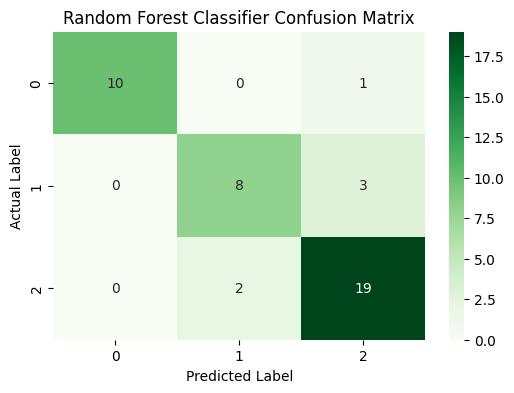

In [16]:
rfc_confusion_matrix = confusion_matrix(ycls_test,rfc_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(rfc_confusion_matrix,annot=True,fmt="d",cmap="Greens")

plt.title("Random Forest Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [17]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest Classifier"],
    "Accuracy": [lgr_accuracy,rfc_accuracy],
    "Precision": [lgr_precision,rfc_precision],
    "Recall": [lgr_recall,rfc_recall],
    "F1-score": [lgr_f1,rfc_f1]
})


classification_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.720930,0.720930,0.720930,0.720930
1,Random Forest Classifier,0.860465,0.863903,0.860465,0.860314


In [18]:
best_classification_model = rfc_model
joblib.dump(best_classification_model, "pkl_files/best_classification_model.pkl")

['pkl_files/best_classification_model.pkl']